In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import pearsonr, spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Configuration ────────────────────────────────────────────────────────────
DATA_PATH = 'merged_all.csv'   # <-- update path if needed

# Metrics to evaluate (column names in the dataset)
ALL_METRICS = [
    'plddt',
    'pae_interaction',
    'iptm',
    'ipSAE_min',
    'esm_pll',
    'rosetta_interface_dG',
    'dG_kcal_mol'
]

# Human-readable labels
METRIC_LABELS = {
    'plddt':               'pLDDT (Global)',
    'pae_interaction':     'PAE Interaction',
    'iptm':                'ipTM',
    'ipSAE_min':           'ipSAE_min (AF3)',
    'esm_pll':             'ESM2 PLL',
    'rosetta_interface_dG':'Rosetta Interface ΔG',
    'dG_kcal_mol':         'ΔG (kcal/mol)'
}

# Color palette per dataset
DATASET_COLORS = {
    'PPB-Affinity':    '#2196F3',
    'PPB-Affinity-AF': '#1565C0',
    'Adaptyv_EGFR_R1': '#FF9800',
    'Adaptyv_EGFR_R2': '#E65100',
    'Adaptyv_NIPAH':   '#4CAF50',
    'Overath':         '#9C27B0'
}

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
})

print('✓ Setup complete')

✓ Setup complete


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')
df.head(3)

Dataset shape: 17,467 rows × 19 columns

Columns: ['dataset', 'source_dataset', 'target', 'binder', 'sequence', 'kd_M', 'pKD', 'binding_binary', 'binding_strength', 'assay_method', 'structure_method', 'design_method', 'plddt', 'pae_interaction', 'iptm', 'ipSAE_min', 'esm_pll', 'rosetta_interface_dG', 'dG_kcal_mol']


,dataset,source_dataset,target,binder,sequence,kd_M,pKD,binding_binary,binding_strength,assay_method,structure_method,design_method,plddt,pae_interaction,iptm,ipSAE_min,esm_pll,rosetta_interface_dG,dG_kcal_mol
0,PPB-Affinity,SKEMPI v2.0,hGH binding protein,Human growth hormone,NaN,9.000000e-10,9.045757,1.0,NaN,SPR,X-RAY DIFFRACTION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PPB-Affinity,SKEMPI v2.0,Angiogenin,Ribonuclease inhibitor,NaN,5.000000e-16,15.301030,1.0,NaN,Other,X-RAY DIFFRACTION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PPB-Affinity,SKEMPI v2.0,Eglin c,Bovine alpha-chymotrypsin,NaN,1.490000e-12,11.826814,1.0,NaN,IASP,X-RAY DIFFRACTION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ── Dataset composition ───────────────────────────────────────────────────────
print('=== Records per dataset ===')
print(df['dataset'].value_counts().to_string())

print('\n=== pKD availability per dataset ===')
pkd_avail = df.groupby('dataset')['pKD'].agg(
    total='size',
    with_pKD=lambda x: x.notna().sum()
)
print(pkd_avail.to_string())

print('\n=== Metric availability (rows with both metric AND pKD) ===')
rows = []
for m in ALL_METRICS:
    total = df[m].notna().sum()
    with_pkd = (df[m].notna() & df['pKD'].notna()).sum()
    rows.append({'metric': METRIC_LABELS[m], 'total_rows': total, 'rows_with_pKD': with_pkd})
avail_df = pd.DataFrame(rows).set_index('metric')
print(avail_df.to_string())

=== Records per dataset ===
dataset
PPB-Affinity       12062
Overath             3676
Adaptyv_NIPAH       1030
Adaptyv_EGFR_R2      402
Adaptyv_EGFR_R1      202
PPB-Affinity-AF       95

=== pKD availability per dataset ===
                 total  with_pKD
dataset                         
Adaptyv_EGFR_R1    202         8
Adaptyv_EGFR_R2    402        55
Adaptyv_NIPAH     1030       102
Overath           3676         0
PPB-Affinity     12062     12062
PPB-Affinity-AF     95        95

=== Metric availability (rows with both metric AND pKD) ===
                      total_rows  rows_with_pKD
metric                                         
pLDDT (Global)              5068            232
PAE Interaction             3968             60
ipTM                        4795            153
ipSAE_min (AF3)             4395            100
ESM2 PLL                     400             53
Rosetta Interface ΔG        3367              0
ΔG (kcal/mol)                 95             95


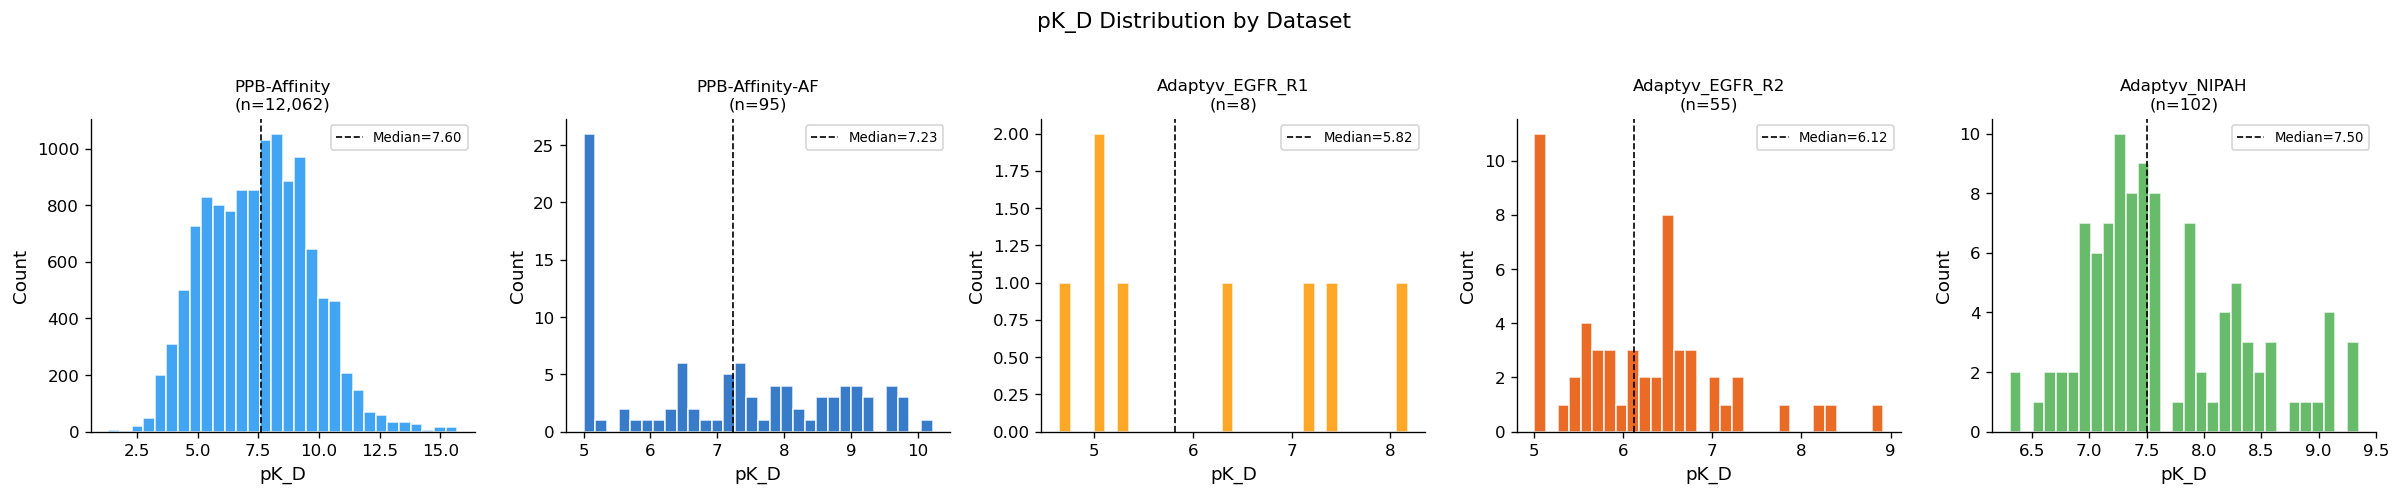

Saved: fig_pkd_distributions.png


In [5]:
# ── pKD distribution by dataset ───────────────────────────────────────────────
datasets_with_pkd = df[df['pKD'].notna()]['dataset'].unique()

fig, axes = plt.subplots(1, len(datasets_with_pkd), figsize=(4 * len(datasets_with_pkd), 4), sharey=False)
if len(datasets_with_pkd) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets_with_pkd):
    sub = df[(df['dataset'] == ds) & df['pKD'].notna()]['pKD']
    ax.hist(sub, bins=30, color=DATASET_COLORS.get(ds, '#888'), edgecolor='white', alpha=0.85)
    ax.set_title(f'{ds}\n(n={len(sub):,})', fontsize=10)
    ax.set_xlabel('pK_D')
    ax.set_ylabel('Count')
    ax.axvline(sub.median(), color='black', linestyle='--', linewidth=1, label=f'Median={sub.median():.2f}')
    ax.legend(fontsize=8)

plt.suptitle('pK_D Distribution by Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_pkd_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_pkd_distributions.png')

In [6]:
# ── Data integrity check: dG_kcal_mol is thermodynamically derived from KD ───
# dG = RT * ln(KD) ≈ -1.364 * pKD at 298K, so correlating it with pKD is circular.
# We EXCLUDE dG_kcal_mol from all regression analyses below.
print('⚠  NOTE: dG_kcal_mol in PPB-Affinity-AF is a thermodynamic transform of KD')
print('   (ΔG = RT·ln(KD) ≈ −1.364 × pKD at 298 K).')
print('   It is excluded from regression — using it would be a circular analysis.')
print('   It is retained in the dataset for reference only.\n')

REGRESSION_METRICS = [m for m in ALL_METRICS if m != 'dG_kcal_mol']

# ── Define analysis subsets ───────────────────────────────────────────────────
# Subsets with pKD AND at least one metric
SUBSETS = {
    'De-novo EGFR (R1+R2)': df[df['dataset'].isin(['Adaptyv_EGFR_R1','Adaptyv_EGFR_R2']) & df['pKD'].notna()].copy(),
    'De-novo NIPAH':         df[(df['dataset'] == 'Adaptyv_NIPAH') & df['pKD'].notna()].copy(),
    'PPB-Affinity-AF':       df[(df['dataset'] == 'PPB-Affinity-AF') & df['pKD'].notna()].copy(),
    'PPB-Affinity (full)':   df[(df['dataset'] == 'PPB-Affinity') & df['pKD'].notna()].copy(),
    'All with pKD':          df[df['pKD'].notna()].copy()
}

for name, sub in SUBSETS.items():
    metrics_avail = [m for m in ALL_METRICS if sub[m].notna().sum() >= 5]
    print(f"[{name}] n={len(sub):,} | metrics available: {[METRIC_LABELS[m] for m in metrics_avail]}")

⚠  NOTE: dG_kcal_mol in PPB-Affinity-AF is a thermodynamic transform of KD
   (ΔG = RT·ln(KD) ≈ −1.364 × pKD at 298 K).
   It is excluded from regression — using it would be a circular analysis.
   It is retained in the dataset for reference only.

[De-novo EGFR (R1+R2)] n=63 | metrics available: ['pLDDT (Global)', 'PAE Interaction', 'ipTM', 'ESM2 PLL']
[De-novo NIPAH] n=102 | metrics available: ['pLDDT (Global)', 'ipTM', 'ipSAE_min (AF3)']
[PPB-Affinity-AF] n=95 | metrics available: ['pLDDT (Global)', 'ΔG (kcal/mol)']
[PPB-Affinity (full)] n=12,062 | metrics available: []
[All with pKD] n=12,322 | metrics available: ['pLDDT (Global)', 'PAE Interaction', 'ipTM', 'ipSAE_min (AF3)', 'ESM2 PLL', 'ΔG (kcal/mol)']


# Simple Regression

In [7]:
def simple_regression_stats(x, y, metric_name, subset_name):
    """Compute correlation stats and OLS for one metric vs pKD."""
    mask = x.notna() & y.notna()
    x_, y_ = x[mask].values, y[mask].values
    n = len(x_)
    if n < 5:
        return None

    r, p_r   = pearsonr(x_, y_)
    rho, p_s = spearmanr(x_, y_)

    # OLS
    X_ols = sm.add_constant(x_)
    model = sm.OLS(y_, X_ols).fit()
    r2    = model.rsquared
    slope = model.params[1]
    intercept = model.params[0]

    return {
        'subset': subset_name,
        'metric': METRIC_LABELS.get(metric_name, metric_name),
        'metric_key': metric_name,
        'n': n,
        'pearson_r': round(r, 4),
        'pearson_p': round(p_r, 4),
        'spearman_rho': round(rho, 4),
        'spearman_p': round(p_s, 4),
        'R2': round(r2, 4),
        'slope': round(slope, 4),
        'intercept': round(intercept, 4),
        'x': x_,
        'y': y_
    }

# Run for all subsets × metrics
all_results = []
for subset_name, sub_df in SUBSETS.items():
    for metric in REGRESSION_METRICS:
        res = simple_regression_stats(sub_df[metric], sub_df['pKD'], metric, subset_name)
        if res:
            all_results.append(res)

results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['x','y']} for r in all_results])
print(f'Total metric×subset combinations with sufficient data: {len(results_df)}')
results_df.head(10)

Total metric×subset combinations with sufficient data: 13


,subset,metric,metric_key,n,pearson_r,pearson_p,spearman_rho,spearman_p,R2,slope,intercept
0,De-novo EGFR (R1+R2),pLDDT (Global),plddt,60,-0.0078,0.9530,-0.1561,0.2335,0.0001,-0.0007,6.1520
1,De-novo EGFR (R1+R2),PAE Interaction,pae_interaction,60,0.2462,0.0580,0.1912,0.1434,0.0606,0.0337,5.5956
2,De-novo EGFR (R1+R2),ipTM,iptm,53,-0.1607,0.2504,-0.1503,0.2826,0.0258,-0.6777,6.6732
3,De-novo EGFR (R1+R2),ESM2 PLL,esm_pll,53,-0.1710,0.2208,-0.2263,0.1032,0.0292,-0.0010,5.9435
4,De-novo NIPAH,pLDDT (Global),plddt,102,-0.1997,0.0442,-0.2252,0.0229,0.0399,-0.0331,10.4269
5,De-novo NIPAH,ipTM,iptm,100,0.1443,0.1522,-0.0668,0.5087,0.0208,0.9678,6.8013
6,De-novo NIPAH,ipSAE_min (AF3),ipSAE_min,100,0.2482,0.0128,0.1981,0.0482,0.0616,0.9248,7.0943
7,PPB-Affinity-AF,pLDDT (Global),plddt,70,0.3771,0.0013,0.4965,0.0000,0.1422,0.1107,-2.9196
8,All with pKD,pLDDT (Global),plddt,232,0.0653,0.3222,-0.0096,0.8838,0.0043,0.0118,5.8784
9,All with pKD,PAE Interaction,pae_interaction,60,0.2462,0.0580,0.1912,0.1434,0.0606,0.0337,5.5956


In [8]:
# ── Full correlation table ────────────────────────────────────────────────────
print('=== Simple Regression Results — All Subsets × Metrics ===')

display_cols = ['subset','metric','n','pearson_r','pearson_p','spearman_rho','spearman_p','R2']
print(results_df[display_cols].sort_values(['subset','R2'], ascending=[True, False]).to_string(index=False))

=== Simple Regression Results — All Subsets × Metrics ===
              subset          metric   n  pearson_r  pearson_p  spearman_rho  spearman_p     R2
        All with pKD ipSAE_min (AF3) 100     0.2482     0.0128        0.1981      0.0482 0.0616
        All with pKD PAE Interaction  60     0.2462     0.0580        0.1912      0.1434 0.0606
        All with pKD        ESM2 PLL  53    -0.1710     0.2208       -0.2263      0.1032 0.0292
        All with pKD            ipTM 153     0.1371     0.0910       -0.0434      0.5944 0.0188
        All with pKD  pLDDT (Global) 232     0.0653     0.3222       -0.0096      0.8838 0.0043
De-novo EGFR (R1+R2) PAE Interaction  60     0.2462     0.0580        0.1912      0.1434 0.0606
De-novo EGFR (R1+R2)        ESM2 PLL  53    -0.1710     0.2208       -0.2263      0.1032 0.0292
De-novo EGFR (R1+R2)            ipTM  53    -0.1607     0.2504       -0.1503      0.2826 0.0258
De-novo EGFR (R1+R2)  pLDDT (Global)  60    -0.0078     0.9530       -0.1561  

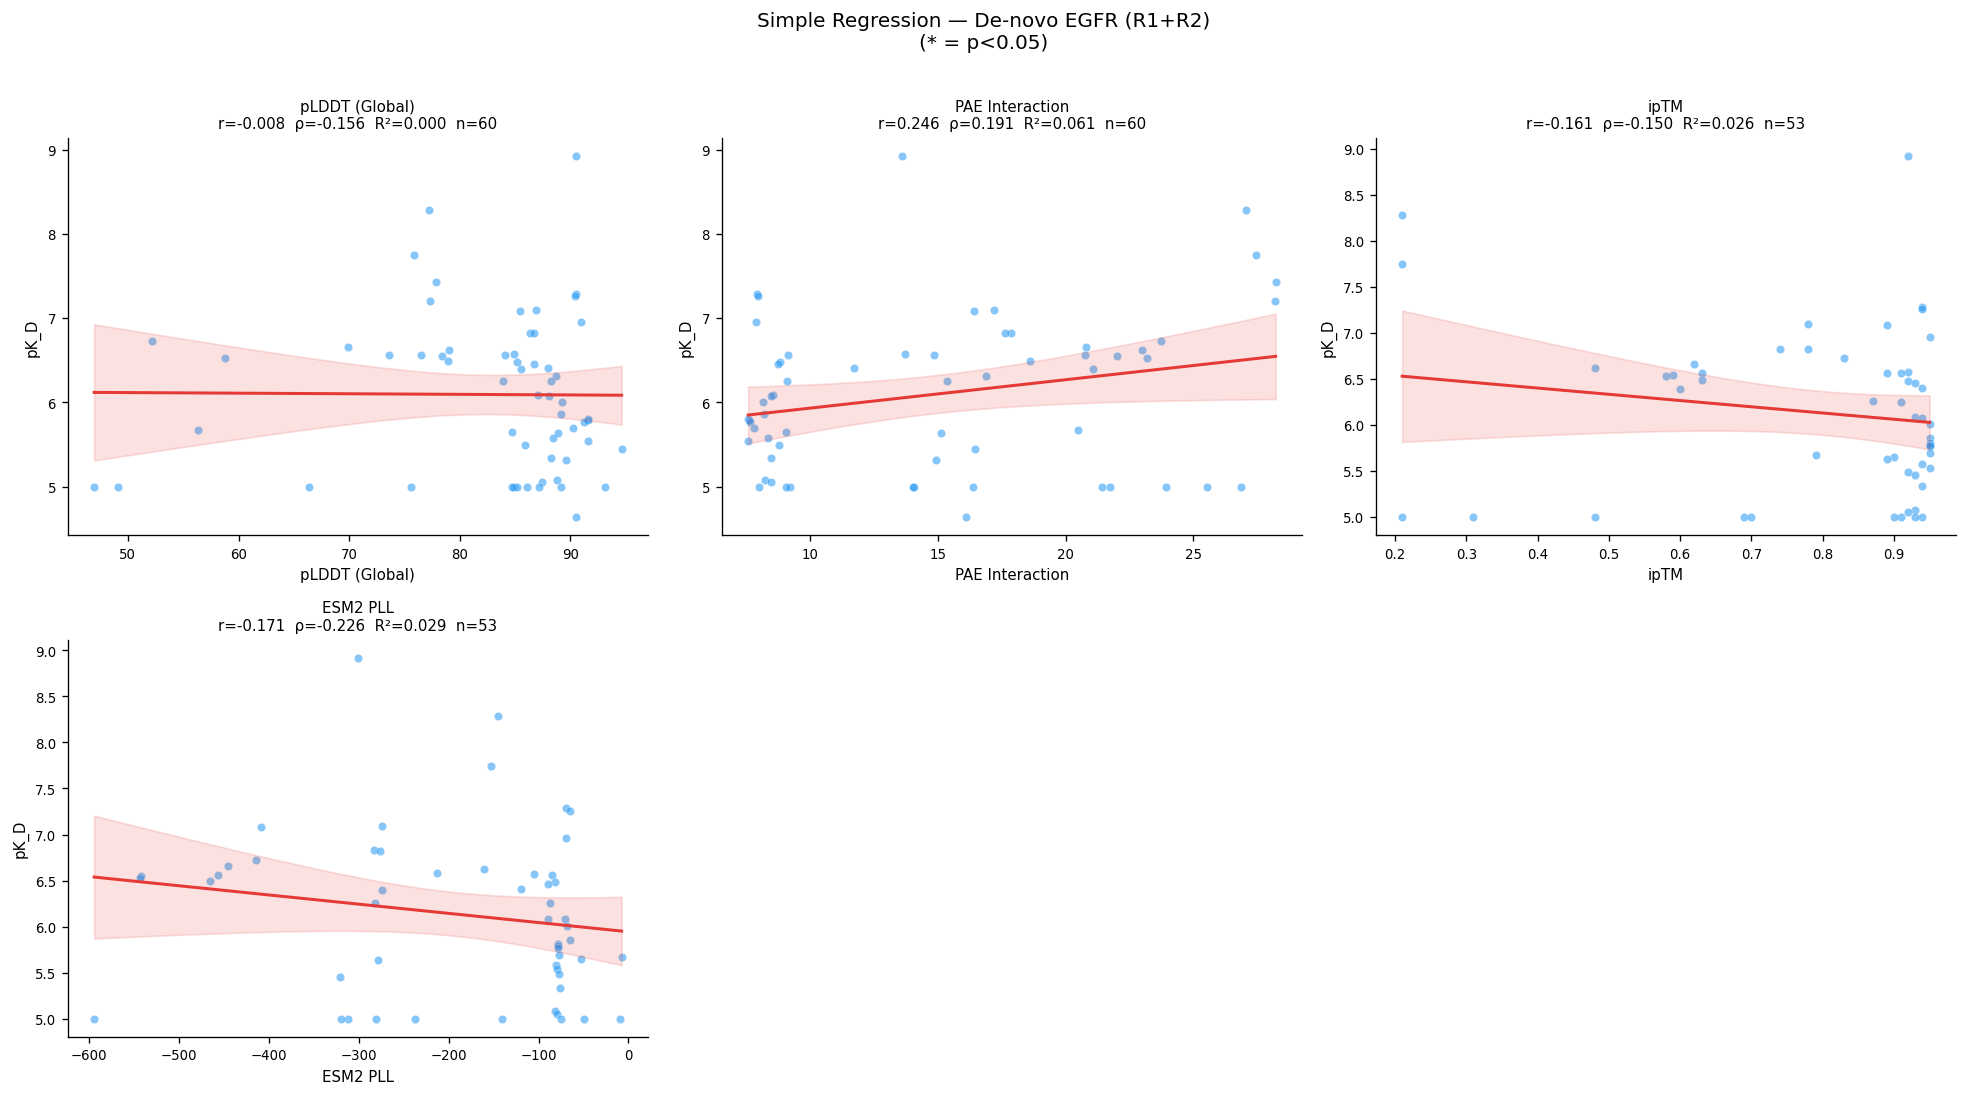

Saved: fig_scatter_De-novo_EGFR_(R1+R2).png


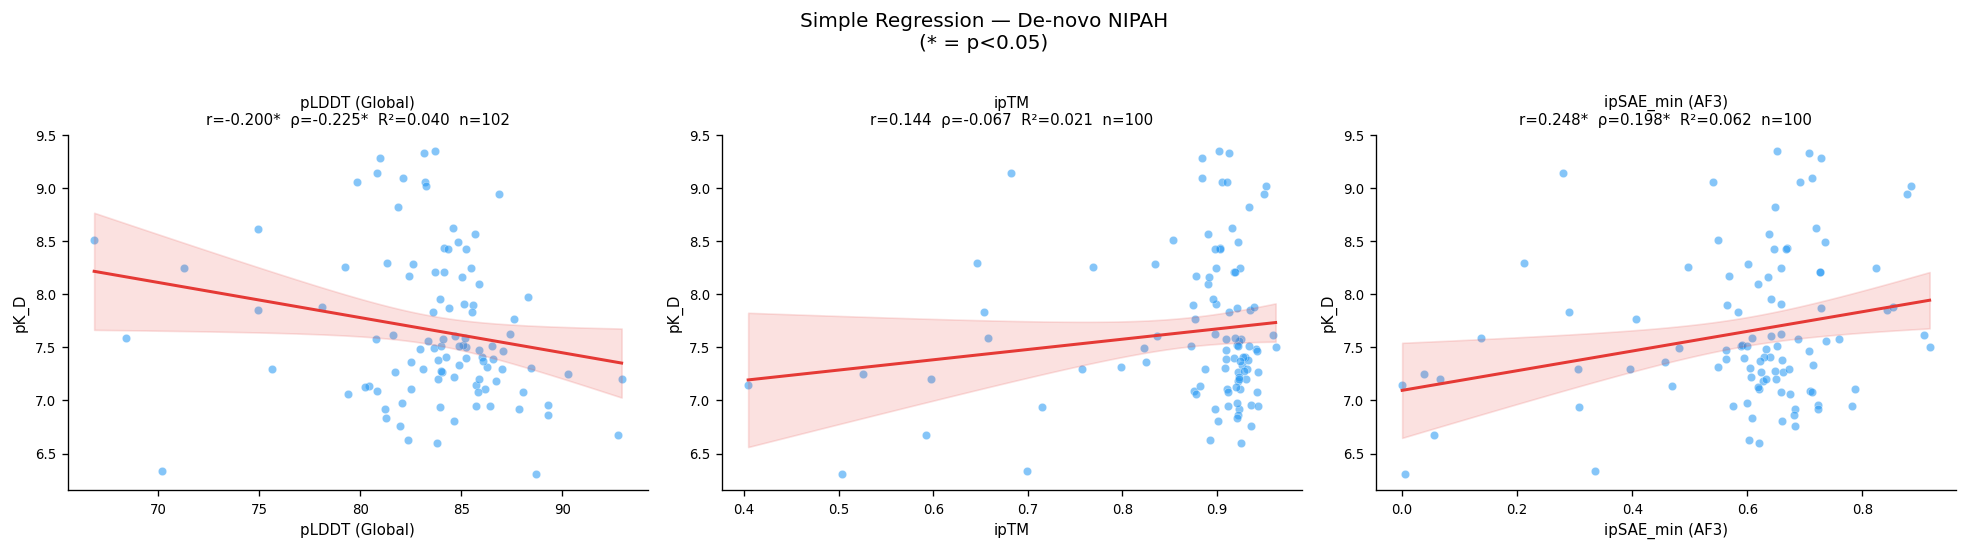

Saved: fig_scatter_De-novo_NIPAH.png


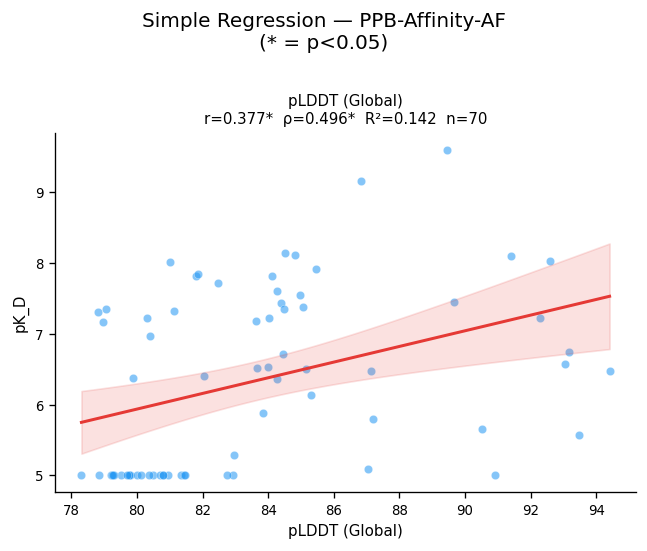

Saved: fig_scatter_PPB-Affinity-AF.png


In [9]:
# ── Scatter plots: one figure per subset ─────────────────────────────────────
def plot_scatter_grid(subset_name, sub_results):
    """Grid of scatter plots for one subset, one panel per metric."""
    if not sub_results:
        return
    ncols = min(3, len(sub_results))
    nrows = int(np.ceil(len(sub_results) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
    axes = np.array(axes).flatten()

    ds_color = '#2196F3'  # default
    # try to pick a color from the subset
    for ds, c in DATASET_COLORS.items():
        if ds.lower() in subset_name.lower():
            ds_color = c
            break

    for i, res in enumerate(sub_results):
        ax = axes[i]
        x_, y_ = res['x'], res['y']
        ax.scatter(x_, y_, alpha=0.55, s=25, color=ds_color, edgecolors='white', linewidths=0.3)

        # Regression line
        x_line = np.linspace(x_.min(), x_.max(), 200)
        y_line = res['slope'] * x_line + res['intercept']
        ax.plot(x_line, y_line, color='#E53935', linewidth=1.8, zorder=5)

        # 95% CI band
        n = len(x_)
        se = np.sqrt(np.sum((y_ - (res['slope']*x_ + res['intercept']))**2) / (n-2))
        x_mean = x_.mean()
        ci = 1.96 * se * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x_ - x_mean)**2))
        ax.fill_between(x_line, y_line - ci, y_line + ci, alpha=0.15, color='#E53935')

        sig_r = '*' if res['pearson_p'] < 0.05 else ''
        sig_s = '*' if res['spearman_p'] < 0.05 else ''
        ax.set_title(
            f"{res['metric']}\n"
            f"r={res['pearson_r']:.3f}{sig_r}  ρ={res['spearman_rho']:.3f}{sig_s}  R²={res['R2']:.3f}  n={n}",
            fontsize=9
        )
        ax.set_xlabel(res['metric'], fontsize=9)
        ax.set_ylabel('pK_D', fontsize=9)
        ax.tick_params(labelsize=8)

    # Hide unused axes
    for j in range(len(sub_results), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Simple Regression — {subset_name}\n(* = p<0.05)', fontsize=12, y=1.01)
    plt.tight_layout()
    fname = f'fig_scatter_{subset_name.replace(" ","_").replace("/","-")}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {fname}')

# Plot per subset (skip full PPB-Affinity to avoid overplotting with 12k+ points)
PLOT_SUBSETS = ['De-novo EGFR (R1+R2)', 'De-novo NIPAH', 'PPB-Affinity-AF']
for subset_name in PLOT_SUBSETS:
    sub_res = [r for r in all_results if r['subset'] == subset_name]
    plot_scatter_grid(subset_name, sub_res)

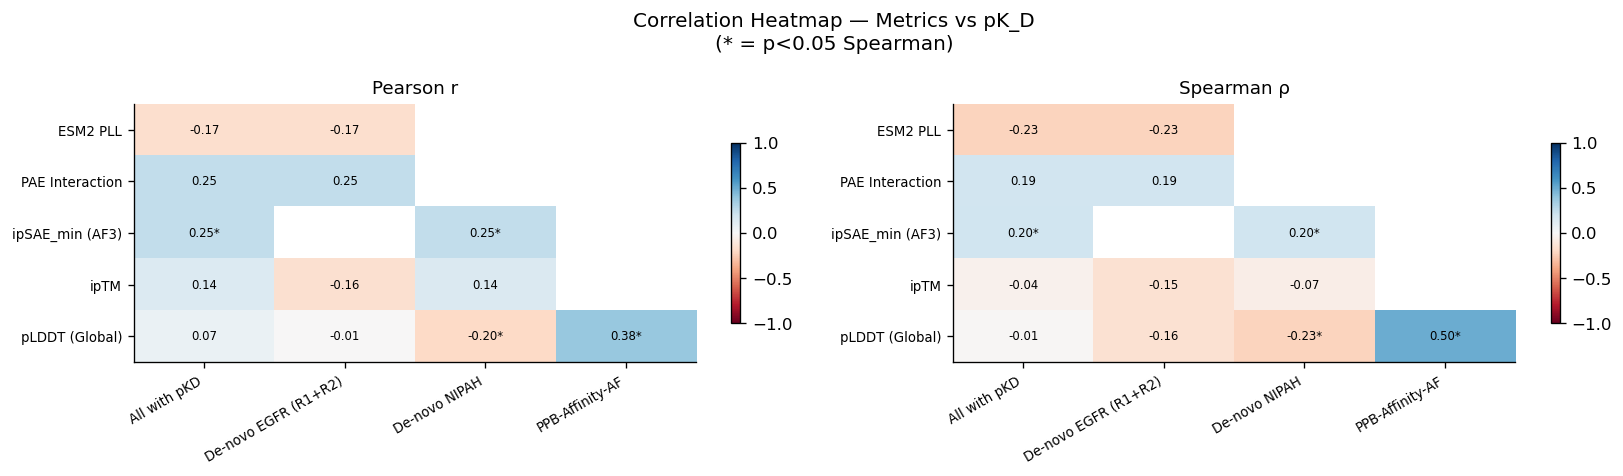

Saved: fig_correlation_heatmap.png


In [10]:
# ── Correlation heatmap: Spearman ρ across subsets × metrics ─────────────────
pivot_r   = results_df.pivot_table(index='metric', columns='subset', values='pearson_r')
pivot_rho = results_df.pivot_table(index='metric', columns='subset', values='spearman_rho')
pivot_p   = results_df.pivot_table(index='metric', columns='subset', values='spearman_p')

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(pivot_rho) * 0.8)))\

for ax, pivot, title, cmap in zip(
    axes,
    [pivot_r, pivot_rho],
    ['Pearson r', 'Spearman ρ'],
    ['RdBu', 'RdBu']
):
    im = ax.imshow(pivot.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.7)

    # Annotate cells
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                # add significance marker from p-table
                try:
                    p_val = pivot_p.values[i, j]
                    sig = '*' if (not np.isnan(p_val) and p_val < 0.05) else ''
                except:
                    sig = ''
                ax.text(j, i, f'{val:.2f}{sig}', ha='center', va='center',
                        fontsize=7, color='black' if abs(val) < 0.6 else 'white')

plt.suptitle('Correlation Heatmap — Metrics vs pK_D\n(* = p<0.05 Spearman)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_correlation_heatmap.png')

# Mulitple Regression

In [11]:
def run_multiple_ols(subset_name, sub_df, min_n=10):
    """Fit OLS with all available metrics for a given subset."""
    available = [m for m in REGRESSION_METRICS if sub_df[m].notna().sum() >= 5]
    if len(available) < 2:
        print(f'[{subset_name}] Skipped — fewer than 2 metrics available.')
        return None

    # Keep only rows with pKD and at least one metric
    sub = sub_df[['pKD'] + available].dropna(subset=['pKD'])

    # For each available metric, fill NaN with median
    complete = sub.dropna(subset=available)
    
    print(f'\n{"="*60}')
    print(f'SUBSET: {subset_name}  |  Complete cases: {len(complete)}  |  Metrics: {[METRIC_LABELS[m] for m in available]}')
    print('='*60)

    if len(complete) < min_n:
        print(f'  → Only {len(complete)} complete cases; running on median-imputed data (n={len(sub)}).')
        for m in available:
            sub[m] = sub[m].fillna(sub[m].median())
        analysis_df = sub
    else:
        analysis_df = complete

    X = analysis_df[available]
    y = analysis_df['pKD']

    # VIF
    print('\n--- Variance Inflation Factors (VIF) ---')
    X_vif = sm.add_constant(X)
    vif_data = pd.DataFrame()
    vif_data['metric'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i+1) for i in range(X.shape[1])]
    vif_data['metric'] = [METRIC_LABELS.get(m, m) for m in X.columns]
    print(vif_data.to_string(index=False))
    if (vif_data['VIF'] > 5).any():
        print('  ⚠  VIF > 5 detected — multicollinearity may inflate coefficient estimates.')

    # OLS
    X_ols = sm.add_constant(X)
    model = sm.OLS(y, X_ols).fit()
    print('\n--- OLS Summary ---')
    print(model.summary())

    return model, available, analysis_df

ols_models = {}
for subset_name, sub_df in SUBSETS.items():
    result = run_multiple_ols(subset_name, sub_df)
    if result:
        ols_models[subset_name] = result


SUBSET: De-novo EGFR (R1+R2)  |  Complete cases: 53  |  Metrics: ['pLDDT (Global)', 'PAE Interaction', 'ipTM', 'ESM2 PLL']

--- Variance Inflation Factors (VIF) ---
         metric      VIF
 pLDDT (Global) 1.924468
PAE Interaction 7.945698
           ipTM 5.098267
       ESM2 PLL 1.909725
  ⚠  VIF > 5 detected — multicollinearity may inflate coefficient estimates.

--- OLS Summary ---
                            OLS Regression Results                            
Dep. Variable:                    pKD   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.8752
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.486
Time:                        13:09:13   Log-Likelihood:                -66.464
No. Observations:                  53   AIC:                             142.9
Df Residuals:                      48   BIC:              

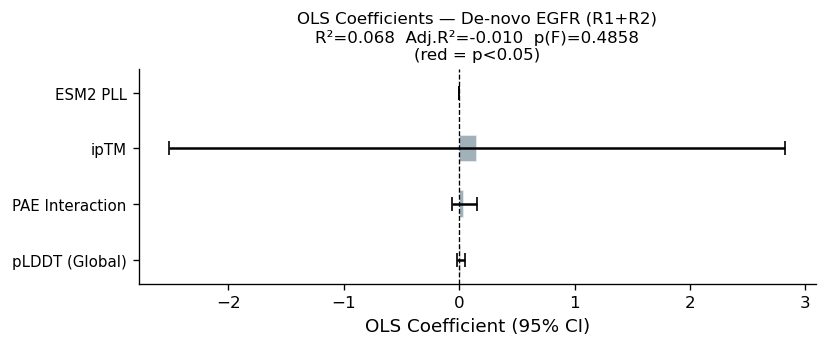

Saved: fig_ols_coefs_De-novo_EGFR_(R1+R2).png


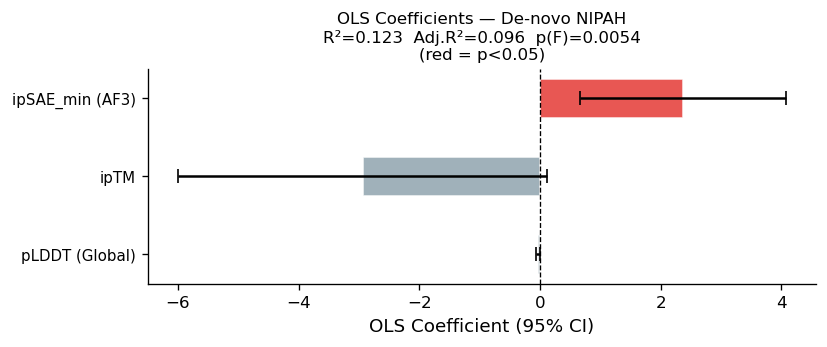

Saved: fig_ols_coefs_De-novo_NIPAH.png


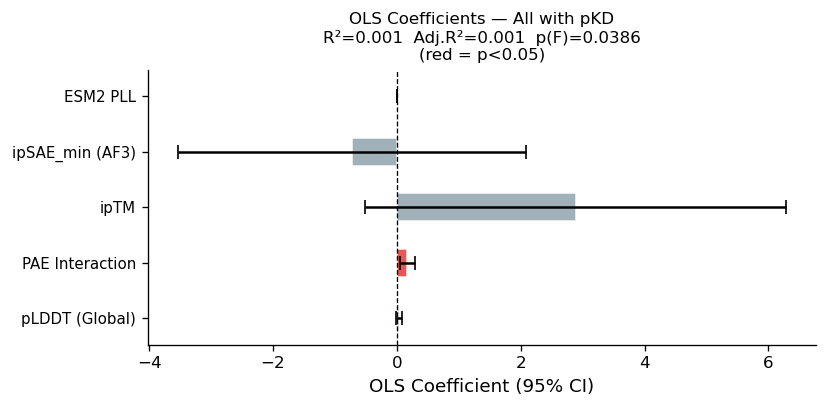

Saved: fig_ols_coefs_All_with_pKD.png


In [12]:
# ── Coefficient plots for each OLS model ─────────────────────────────────────
def plot_coefficients(model, available_metrics, subset_name):
    params = model.params.drop('const', errors='ignore')
    conf   = model.conf_int().drop('const', errors='ignore')
    labels = [METRIC_LABELS.get(m, m) for m in params.index]
    errors = np.array([(params[i] - conf.iloc[i, 0], conf.iloc[i, 1] - params[i])
                       for i in range(len(params))]).T

    colors = ['#E53935' if p < 0.05 else '#90A4AE' for p in model.pvalues.drop('const', errors='ignore')]

    fig, ax = plt.subplots(figsize=(7, max(3, len(params) * 0.7)))
    y_pos = np.arange(len(params))
    ax.barh(y_pos, params.values, xerr=errors, color=colors, edgecolor='white',
            height=0.5, capsize=4, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('OLS Coefficient (95% CI)')
    ax.set_title(
        f'OLS Coefficients — {subset_name}\n'
        f'R²={model.rsquared:.3f}  Adj.R²={model.rsquared_adj:.3f}  p(F)={model.f_pvalue:.4f}\n'
        f'(red = p<0.05)',
        fontsize=10
    )
    plt.tight_layout()
    fname = f'fig_ols_coefs_{subset_name.replace(" ","_").replace("/","-")}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {fname}')

for subset_name, (model, available, _) in ols_models.items():
    plot_coefficients(model, available, subset_name)

# Non-linear Models

In [13]:
def run_nonlinear_models(subset_name, sub_df, min_n=15, n_cv=5):
    """Fit RF and GBM with CV, return feature importances."""
    available = [m for m in REGRESSION_METRICS if sub_df[m].notna().sum() >= 5]
    if len(available) < 1:
        print(f'[{subset_name}] Skipped — no metrics available.')
        return None

    sub = sub_df[['pKD'] + available].dropna(subset=['pKD']).copy()
    # Median imputation for missing metric values
    for m in available:
        sub[m] = sub[m].fillna(sub[m].median())
    sub = sub.dropna()

    if len(sub) < min_n:
        print(f'[{subset_name}] Skipped — only {len(sub)} complete rows.')
        return None

    X = sub[available].values
    y = sub['pKD'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    cv = KFold(n_splits=min(n_cv, len(sub)//3), shuffle=True, random_state=42)

    results = {}
    for name, model in [
        ('Random Forest',       RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
        ('Gradient Boosting',   GradientBoostingRegressor(n_estimators=200, random_state=42))
    ]:
        cv_r2 = cross_val_score(model, X_scaled, y, cv=cv, scoring='r2')
        cv_mse = cross_val_score(model, X_scaled, y, cv=cv, scoring='neg_mean_squared_error')
        model.fit(X_scaled, y)
        y_pred = model.predict(X_scaled)
        train_r2 = r2_score(y, y_pred)

        # Permutation importance on full set
        perm = permutation_importance(model, X_scaled, y, n_repeats=20, random_state=42)

        results[name] = {
            'cv_r2_mean': cv_r2.mean(),
            'cv_r2_std':  cv_r2.std(),
            'train_r2':   train_r2,
            'cv_rmse':    np.sqrt(-cv_mse.mean()),
            'model':      model,
            'perm_imp_mean': perm.importances_mean,
            'perm_imp_std':  perm.importances_std
        }
        print(f'[{subset_name}] {name}: CV R²={cv_r2.mean():.3f}±{cv_r2.std():.3f}  Train R²={train_r2:.3f}  CV RMSE={np.sqrt(-cv_mse.mean()):.3f}')

    return results, available, sub


nonlinear_results = {}
for subset_name, sub_df in SUBSETS.items():
    if subset_name == 'All with pKD':
        continue  # skip mega-set for speed
    print(f'\n--- {subset_name} ---')
    res = run_nonlinear_models(subset_name, sub_df)
    if res:
        nonlinear_results[subset_name] = res


--- De-novo EGFR (R1+R2) ---
[De-novo EGFR (R1+R2)] Random Forest: CV R²=-0.112±0.203  Train R²=0.822  CV RMSE=0.996
[De-novo EGFR (R1+R2)] Gradient Boosting: CV R²=-0.387±0.562  Train R²=0.950  CV RMSE=1.123

--- De-novo NIPAH ---
[De-novo NIPAH] Random Forest: CV R²=-0.120±0.438  Train R²=0.867  CV RMSE=0.684
[De-novo NIPAH] Gradient Boosting: CV R²=-0.367±0.918  Train R²=0.993  CV RMSE=0.727

--- PPB-Affinity-AF ---
[PPB-Affinity-AF] Random Forest: CV R²=0.531±0.179  Train R²=0.919  CV RMSE=1.088
[PPB-Affinity-AF] Gradient Boosting: CV R²=0.428±0.207  Train R²=0.973  CV RMSE=1.182

--- PPB-Affinity (full) ---
[PPB-Affinity (full)] Skipped — no metrics available.


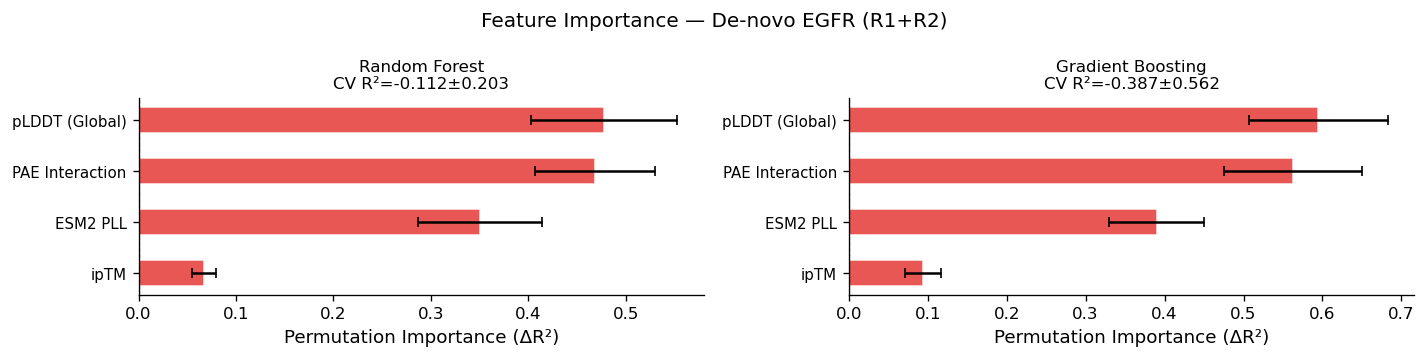

Saved: fig_importance_De-novo_EGFR_(R1+R2).png


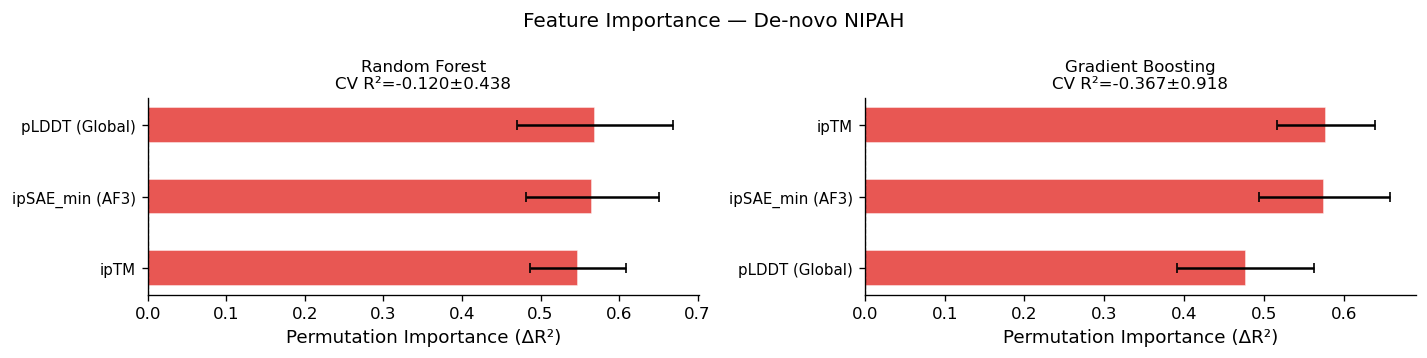

Saved: fig_importance_De-novo_NIPAH.png


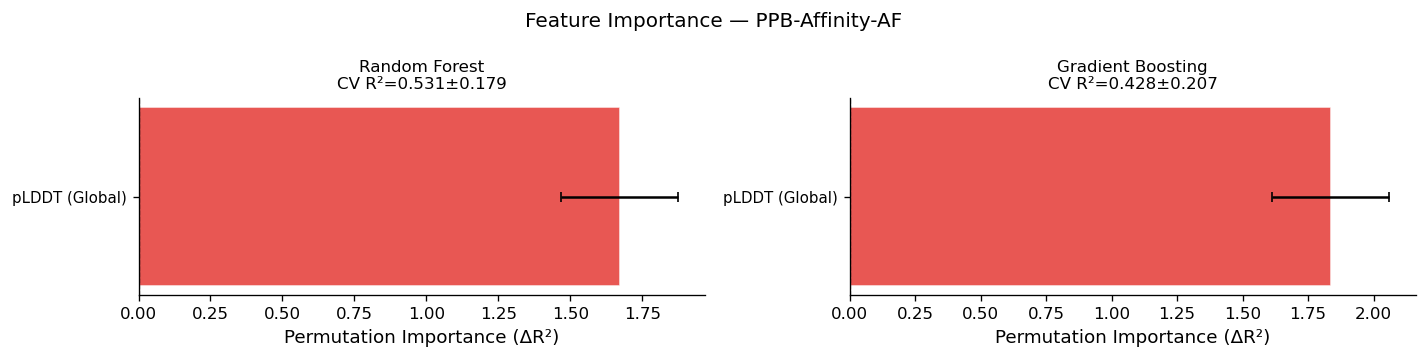

Saved: fig_importance_PPB-Affinity-AF.png


In [14]:
# ── Feature importance plots ──────────────────────────────────────────────────
for subset_name, (model_dict, available, sub) in nonlinear_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, max(3, len(available) * 0.7)))
    metric_labels = [METRIC_LABELS.get(m, m) for m in available]

    for ax, (model_name, res) in zip(axes, model_dict.items()):
        imp    = res['perm_imp_mean']
        imp_sd = res['perm_imp_std']
        order  = np.argsort(imp)
        colors = ['#E53935' if imp[i] > 0 else '#90A4AE' for i in order]

        ax.barh(
            range(len(order)),
            imp[order],
            xerr=imp_sd[order],
            color=colors,
            edgecolor='white',
            height=0.5,
            capsize=3,
            alpha=0.85
        )
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels([metric_labels[i] for i in order], fontsize=9)
        ax.axvline(0, color='black', linewidth=0.7, linestyle='--')
        ax.set_xlabel('Permutation Importance (ΔR²)')
        ax.set_title(
            f'{model_name}\nCV R²={res["cv_r2_mean"]:.3f}±{res["cv_r2_std"]:.3f}',
            fontsize=10
        )

    fig.suptitle(f'Feature Importance — {subset_name}', fontsize=12)
    plt.tight_layout()
    fname = f'fig_importance_{subset_name.replace(" ","_").replace("/","-")}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {fname}')

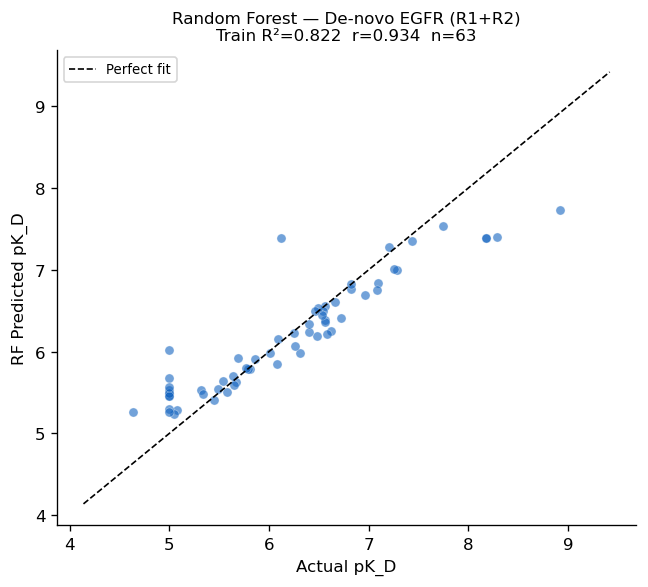

Saved: fig_rf_predicted_De-novo_EGFR_(R1+R2).png


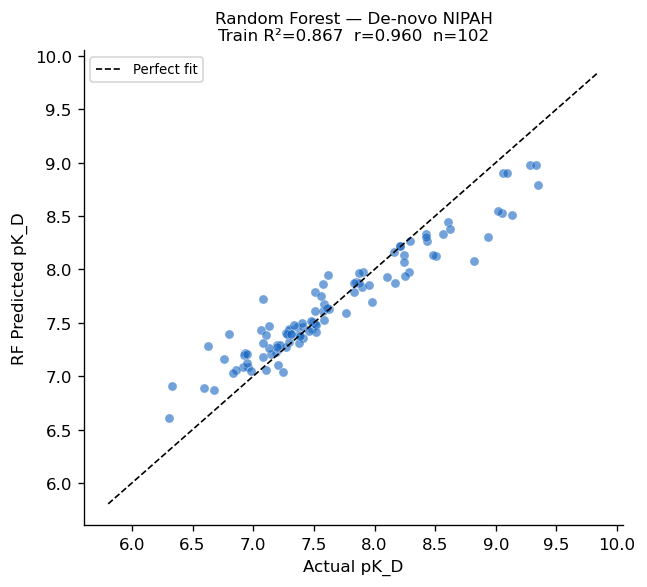

Saved: fig_rf_predicted_De-novo_NIPAH.png


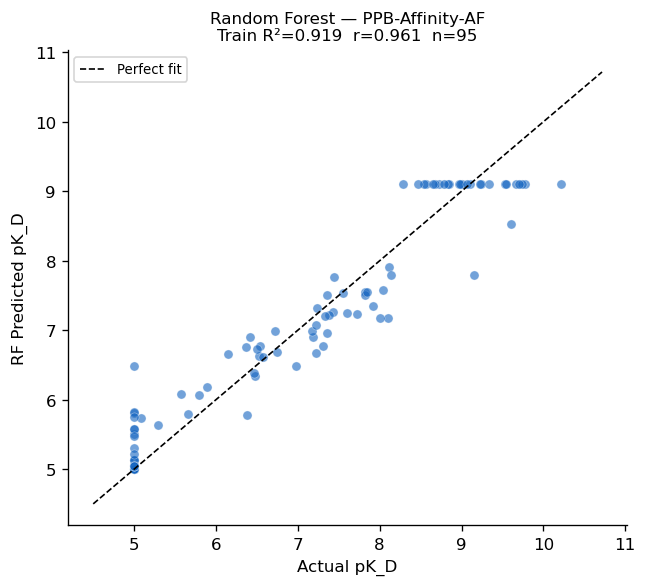

Saved: fig_rf_predicted_PPB-Affinity-AF.png


In [15]:
# ── Predicted vs Actual plots ─────────────────────────────────────────────────
for subset_name, (model_dict, available, sub) in nonlinear_results.items():
    rf_model = model_dict['Random Forest']['model']

    X = sub[available].copy()
    for m in available:
        X[m] = X[m].fillna(X[m].median())
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X.values)
    y_true = sub['pKD'].values
    y_pred = rf_model.predict(X_s)

    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.scatter(y_true, y_pred, alpha=0.6, s=30, color='#1565C0', edgecolors='white', linewidths=0.3)
    lims = [min(y_true.min(), y_pred.min()) - 0.5, max(y_true.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')
    r2 = r2_score(y_true, y_pred)
    r_p, _ = pearsonr(y_true, y_pred)
    ax.set_xlabel('Actual pK_D', fontsize=10)
    ax.set_ylabel('RF Predicted pK_D', fontsize=10)
    ax.set_title(f'Random Forest — {subset_name}\nTrain R²={r2:.3f}  r={r_p:.3f}  n={len(y_true)}', fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout()
    fname = f'fig_rf_predicted_{subset_name.replace(" ","_").replace("/","-")}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {fname}')

# Summary

In [16]:
# ── Build comprehensive summary ───────────────────────────────────────────────
summary = results_df[['subset','metric','n','pearson_r','pearson_p','spearman_rho','spearman_p','R2']].copy()

# Significance flags
summary['sig_pearson']  = summary['pearson_p'].apply(lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))
summary['sig_spearman'] = summary['spearman_p'].apply(lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))

print('=== COMPREHENSIVE REGRESSION SUMMARY ===')
print('Significance: * p<0.05  ** p<0.01  *** p<0.001')
print()

for subset in summary['subset'].unique():
    sub_sum = summary[summary['subset'] == subset].sort_values('R2', ascending=False)
    print(f"\n{'─'*70}")
    print(f"  {subset}")
    print(f"{'─'*70}")
    print(f"  {'Metric':<25} {'n':>5} {'Pearson r':>10} {'Sig':>4} {'Spearman ρ':>11} {'Sig':>4} {'R²':>7}")
    print(f"  {'-'*25} {'─'*5} {'─'*10} {'─'*4} {'─'*11} {'─'*4} {'─'*7}")
    for _, row in sub_sum.iterrows():
        print(f"  {row['metric']:<25} {int(row['n']):>5} {row['pearson_r']:>10.3f} {row['sig_pearson']:>4} {row['spearman_rho']:>11.3f} {row['sig_spearman']:>4} {row['R2']:>7.4f}")

# Export to CSV
summary.to_csv('regression_summary.csv', index=False)
print(f'\n✓ Saved full summary table: regression_summary.csv')

=== COMPREHENSIVE REGRESSION SUMMARY ===
Significance: * p<0.05  ** p<0.01  *** p<0.001


──────────────────────────────────────────────────────────────────────
  De-novo EGFR (R1+R2)
──────────────────────────────────────────────────────────────────────
  Metric                        n  Pearson r  Sig  Spearman ρ  Sig      R²
  ------------------------- ───── ────────── ──── ─────────── ──── ───────
  PAE Interaction              60      0.246            0.191       0.0606
  ESM2 PLL                     53     -0.171           -0.226       0.0292
  ipTM                         53     -0.161           -0.150       0.0258
  pLDDT (Global)               60     -0.008           -0.156       0.0001

──────────────────────────────────────────────────────────────────────
  De-novo NIPAH
──────────────────────────────────────────────────────────────────────
  Metric                        n  Pearson r  Sig  Spearman ρ  Sig      R²
  ------------------------- ───── ────────── ──── ───────────

In [17]:
# ── Non-linear model summary ──────────────────────────────────────────────────
print('=== NON-LINEAR MODEL SUMMARY (Cross-validated R²) ===')
print(f"{'Subset':<30} {'Model':<22} {'CV R²':>8} {'±':>4} {'Train R²':>10} {'CV RMSE':>9}")
print('─' * 85)

for subset_name, (model_dict, available, _) in nonlinear_results.items():
    for model_name, res in model_dict.items():
        print(f"{subset_name:<30} {model_name:<22} {res['cv_r2_mean']:>8.3f} {res['cv_r2_std']:>4.3f} {res['train_r2']:>10.3f} {res['cv_rmse']:>9.3f}")

=== NON-LINEAR MODEL SUMMARY (Cross-validated R²) ===
Subset                         Model                     CV R²    ±   Train R²   CV RMSE
─────────────────────────────────────────────────────────────────────────────────────
De-novo EGFR (R1+R2)           Random Forest            -0.112 0.203      0.822     0.996
De-novo EGFR (R1+R2)           Gradient Boosting        -0.387 0.562      0.950     1.123
De-novo NIPAH                  Random Forest            -0.120 0.438      0.867     0.684
De-novo NIPAH                  Gradient Boosting        -0.367 0.918      0.993     0.727
PPB-Affinity-AF                Random Forest             0.531 0.179      0.919     1.088
PPB-Affinity-AF                Gradient Boosting         0.428 0.207      0.973     1.182


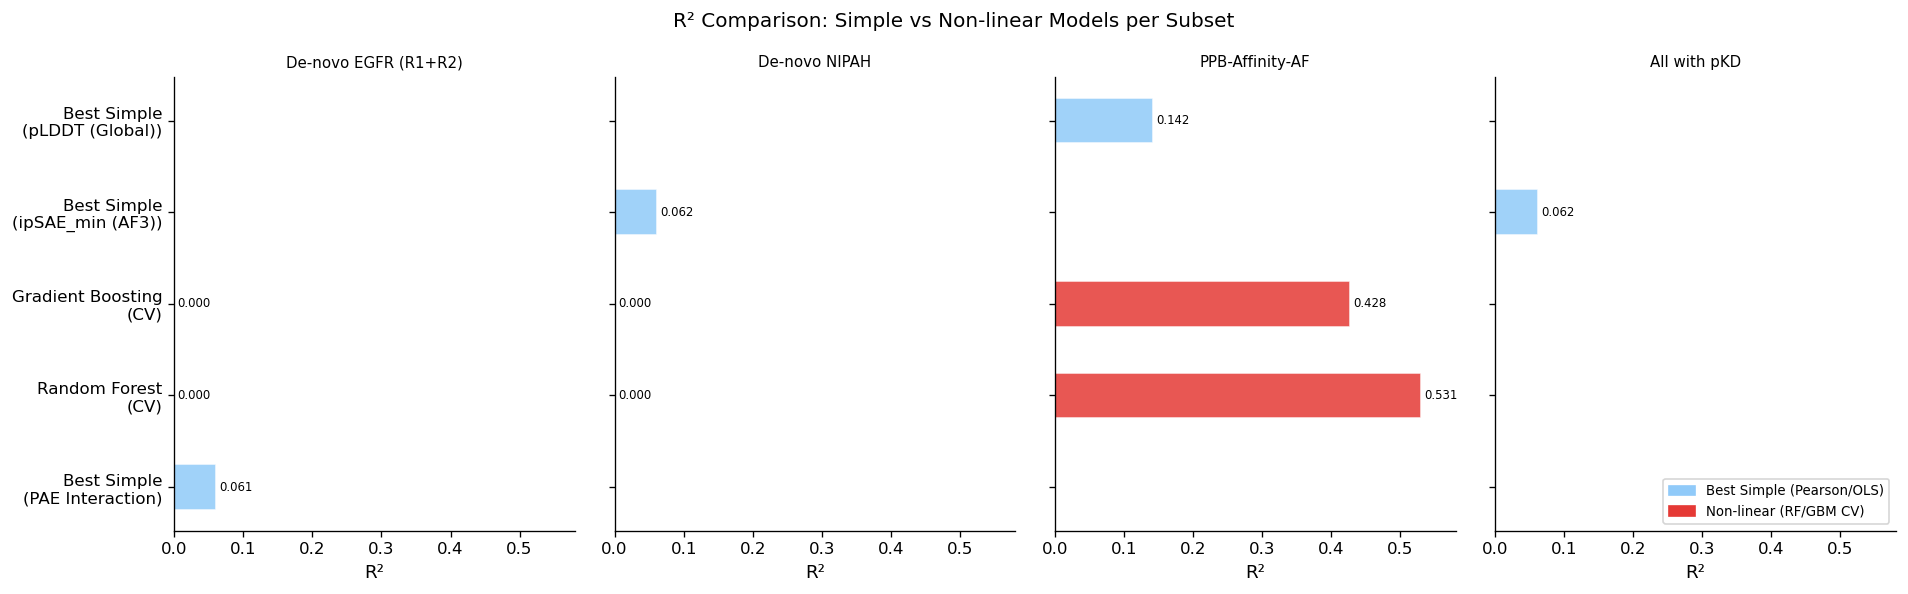

Saved: fig_r2_comparison.png


In [18]:
# ── Bar chart: R² comparison — simple vs non-linear per subset ───────────────
summary_rows = []

# Best simple regression R² per subset
for subset, grp in results_df.groupby('subset'):
    best_r2 = grp['R2'].max()
    best_m  = grp.loc[grp['R2'].idxmax(), 'metric']
    summary_rows.append({'subset': subset, 'model': f'Best Simple\n({best_m})', 'R2': best_r2, 'type': 'simple'})

# RF CV R² per subset
for subset_name, (model_dict, _, _) in nonlinear_results.items():
    for mname, res in model_dict.items():
        summary_rows.append({'subset': subset_name, 'model': mname + '\n(CV)', 'R2': max(res['cv_r2_mean'], 0), 'type': 'nonlinear'})

comp_df = pd.DataFrame(summary_rows)

subsets_ordered = [s for s in SUBSETS.keys() if s in comp_df['subset'].unique()]
fig, axes = plt.subplots(1, len(subsets_ordered), figsize=(4 * len(subsets_ordered), 5), sharey=True)
if len(subsets_ordered) == 1:
    axes = [axes]

model_colors = {
    'simple':    '#90CAF9',
    'nonlinear': '#E53935'
}

for ax, subset in zip(axes, subsets_ordered):
    sub = comp_df[comp_df['subset'] == subset]
    colors = [model_colors[t] for t in sub['type']]
    bars = ax.barh(sub['model'], sub['R2'], color=colors, edgecolor='white', height=0.5, alpha=0.85)
    ax.set_xlim(0, max(comp_df['R2'].max() + 0.05, 0.3))
    ax.set_title(subset, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('R²')
    for bar, val in zip(bars, sub['R2']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(color='#90CAF9', label='Best Simple (Pearson/OLS)'),
                   Patch(color='#E53935', label='Non-linear (RF/GBM CV)')]
axes[-1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.suptitle('R² Comparison: Simple vs Non-linear Models per Subset', fontsize=12)
plt.tight_layout()
plt.savefig('fig_r2_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_r2_comparison.png')

# Discussion

In [19]:
# ── Quick summary printout ────────────────────────────────────────────────────
print('=== QUICK FINDINGS SUMMARY ===')
print()
print('Top metric × subset combinations by Pearson |r|:')
top = results_df.assign(abs_r=results_df['pearson_r'].abs()).sort_values('abs_r', ascending=False).head(10)
for _, row in top.iterrows():
    sig = '***' if row['pearson_p'] < 0.001 else ('**' if row['pearson_p'] < 0.01 else ('*' if row['pearson_p'] < 0.05 else 'n.s.'))
    print(f"  {row['metric']:<25} | {row['subset']:<30} | r={row['pearson_r']:>7.3f} {sig:>5} | R²={row['R2']:.4f} | n={int(row['n'])}")

print()
print('Top metric × subset combinations by Spearman |ρ|:')
top_s = results_df.assign(abs_rho=results_df['spearman_rho'].abs()).sort_values('abs_rho', ascending=False).head(10)
for _, row in top_s.iterrows():
    sig = '***' if row['spearman_p'] < 0.001 else ('**' if row['spearman_p'] < 0.01 else ('*' if row['spearman_p'] < 0.05 else 'n.s.'))
    print(f"  {row['metric']:<25} | {row['subset']:<30} | ρ={row['spearman_rho']:>7.3f} {sig:>5} | n={int(row['n'])}")

=== QUICK FINDINGS SUMMARY ===

Top metric × subset combinations by Pearson |r|:
  pLDDT (Global)            | PPB-Affinity-AF                | r=  0.377    ** | R²=0.1422 | n=70
  ipSAE_min (AF3)           | De-novo NIPAH                  | r=  0.248     * | R²=0.0616 | n=100
  ipSAE_min (AF3)           | All with pKD                   | r=  0.248     * | R²=0.0616 | n=100
  PAE Interaction           | De-novo EGFR (R1+R2)           | r=  0.246  n.s. | R²=0.0606 | n=60
  PAE Interaction           | All with pKD                   | r=  0.246  n.s. | R²=0.0606 | n=60
  pLDDT (Global)            | De-novo NIPAH                  | r= -0.200     * | R²=0.0399 | n=102
  ESM2 PLL                  | De-novo EGFR (R1+R2)           | r= -0.171  n.s. | R²=0.0292 | n=53
  ESM2 PLL                  | All with pKD                   | r= -0.171  n.s. | R²=0.0292 | n=53
  ipTM                      | De-novo EGFR (R1+R2)           | r= -0.161  n.s. | R²=0.0258 | n=53
  ipTM                      | De-n

Classification AUC is strong (≥0.67) while regression R2 remains near zero, supporting the Gatekeeper Hypothesis — AI metrics function as structural plausibility filters, not continuous affinity predictors.